<a href="https://www.kaggle.com/code/mdtahmedulhassan/gold-price-prediction-random-forest-regressor?scriptVersionId=309101580" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Gold Price Prediction 💰

## Objective
### Predict gold prices using financial indicators like SPX, GLD, USO, SLV, EUR/USD.

## Why this matters?
### Gold is a hedge against inflation, so predicting it helps investors.

## Importing all the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

## Loading the data as df

In [2]:
df = pd.read_csv('/kaggle/input/datasets/altruistdelhite04/gold-price-data/gld_price_data.csv')

## Exploratory Data Analysis (EDA)

In [3]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [5]:
df.isna().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


## Dropping the Date Column


In [8]:
df.drop(columns=['Date'],inplace=True)
df.head(3)

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.180,1.471692
1,1447.160034,85.570000,78.370003,15.285,1.474491
2,1411.630005,85.129997,77.309998,15.167,1.475492


## Correlation Heatmap

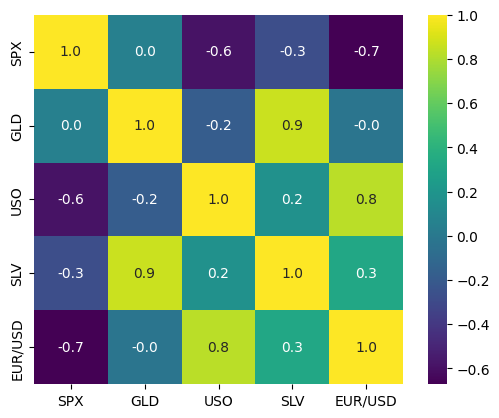

In [9]:
sns.heatmap(df.corr(),annot=True,cbar=True,square=True,fmt='.1f',cmap='viridis')
plt.show()

## Correlation with the GLD column

In [10]:
df.corr().GLD

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64

## Distribution Plot of GLD

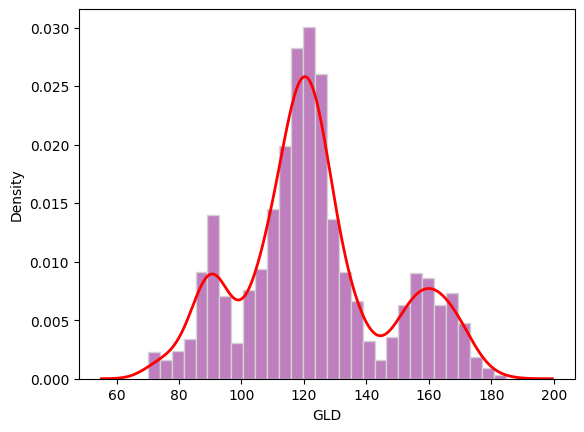

In [11]:
sns.histplot(df['GLD'], stat='density', bins=30, color='purple',alpha=.5,edgecolor='lightgrey')
sns.kdeplot(df['GLD'], color='red', linewidth=2)
plt.show()

## Splitting the predictor and target columns

In [12]:
x=df.drop(columns='GLD')
y=df['GLD']

In [13]:
x.head()

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492
3,1416.180054,75.500000,15.053,1.468299
4,1390.189941,76.059998,15.590,1.557099


In [14]:
y.head()

0    84.860001
1    85.570000
2    85.129997
3    84.769997
4    86.779999
Name: GLD, dtype: float64

## Generating train and test data

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=42)

### Splits data into 80% training and 20% testing. random_state=42 ensures reproducibility.

## Model Training by Random Forest Regressor

In [16]:
model= RandomForestRegressor(n_estimators=100)

### Building and training a Random Forest — an ensemble of 100 decision trees. Each tree learns slightly different patterns; their average forms the final prediction.

In [17]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [18]:
y_prediction=model.predict(x_test)

In [19]:
print(y_prediction)

[122.55019973 130.24850274 127.6201997   96.55859696 118.95210075
 114.40849954 124.97190131 117.70779896 108.04900125  98.03719944
  95.23219962 167.8193984  149.35680095 115.65410005 170.91010107
  84.81449974 123.28139886 109.39499725 113.30090095 131.47710363
 124.30009894 113.86220094 115.54680035 108.64439934 108.77860213
 125.76769907 118.86300012 112.21579893 113.48330155 125.51359884
 146.07400139  89.6453003  168.0231998  113.50589934 108.55990097
 120.11790119 142.97509869 161.32170143 174.01479765 153.20910189
 119.42750113 113.6397005  121.35709941 113.74929928 122.06310014
 107.81470071  88.55509897 114.48739918 129.66490218 118.1850008
 104.09430023 129.67680227 107.20179848 160.42090309 131.77409935
 118.10789951 146.63050087 134.99940259  95.49470103 124.53470172
 115.32589873  86.16260083 104.26409929 113.95620052  84.1180993
 122.2073003  116.52259939 113.61000183 164.98160218  92.23860013
  79.88580075 161.03750051 158.71830241 106.47770012 148.79680147
 109.4330975

## Calculating R-squared score

In [20]:
r2=metrics.r2_score(y_test,y_prediction)
print('The value of R-squared is:',r2)

The value of R-squared is: 0.9898940336985703


### R² (coefficient of determination) measures how well the model explains variance in gold prices. A score close to 1.0 is excellent and R-squared score of our model is .99 which indicates our model is good. 

## Comparing the actual and predicted data using a plot

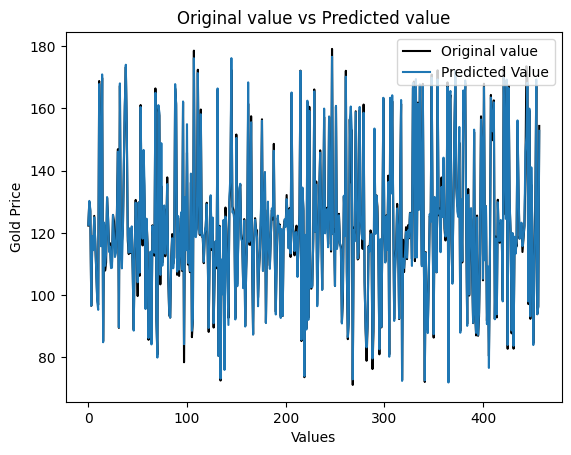

In [21]:
y_test=list(y_test)
plt.plot(y_test,color='black',label='Original value')
plt.plot(y_prediction,label='Predicted Value')
plt.title('Original value vs Predicted value')
plt.legend(loc='upper right')
plt.xlabel('Values')
plt.ylabel('Gold Price')
plt.show()